In [1]:
# === CELL 1: Imports and Setup ===
"""
Offline Training Notebook

This notebook:
1. Loads feature dataset
2. Performs chronological train/test split
3. Trains CatBoost classifier
4. Evaluates model performance
5. Saves model and artifacts

Outputs:
- /artifacts/offline_model/model.cbm
- /artifacts/offline_model/selected_features.json
- /artifacts/offline_model/metrics.json
- /artifacts/offline_model/feature_importance.csv
- /artifacts/offline_model/config_snapshot.json
- /artifacts/offline_model/*.png
"""
import sys
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    brier_score_loss,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve

# Robust project root discovery
ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))
from utils import load_config, config_hash


In [2]:
# === CELL 2: Load Configuration and Data ===
download_config = load_config(ROOT / "config" / "download.yaml")
model_config = load_config(ROOT / "config" / "model.yaml")

SYMBOL = download_config["symbol"]
TRAIN_FRAC = model_config["train_fraction"]
VAL_FRAC = model_config.get("val_fraction", 0.2)
TOP_K = model_config["top_k_features"]

MODEL_DATA_PATH = ROOT / "data" / "model_data" / SYMBOL
ARTIFACT_PATH = ROOT / "artifacts" / "offline_model"
ARTIFACT_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(MODEL_DATA_PATH / "bars_20m_features.parquet")
with open(MODEL_DATA_PATH / "feature_metadata.json") as f:
    feature_meta = json.load(f)

feature_cols = feature_meta["feature_names"]
print(f"Samples: {len(df):,}, Features: {len(feature_cols)}")


Samples: 78,714, Features: 726


In [3]:
# === CELL 3: Chronological Split ===
split_idx = int(len(df) * TRAIN_FRAC)
train_full_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

val_size = int(len(train_full_df) * VAL_FRAC)
val_size = max(val_size, 1) if len(train_full_df) >= 2 else 0

if val_size > 0 and val_size < len(train_full_df):
    train_df = train_full_df.iloc[:-val_size].copy()
    val_df = train_full_df.iloc[-val_size:].copy()
else:
    train_df = train_full_df.copy()
    val_df = train_full_df.iloc[0:0].copy()

X_train = train_df[feature_cols]
y_train = train_df["label"]
X_val = val_df[feature_cols]
y_val = val_df["label"]
X_test = test_df[feature_cols]
y_test = test_df["label"]

print(f"Train: {len(train_df):,} ({y_train.mean():.3%} positive)")
print(f"Val:   {len(val_df):,} ({y_val.mean():.3%} positive)" if len(val_df) else "Val:   0 (skipped)")
print(f"Test:  {len(test_df):,} ({y_test.mean():.3%} positive)")


Train: 37,783 (9.676% positive)
Val:   9,445 (11.329% positive)
Test:  31,486 (9.706% positive)


In [4]:
# === CELL 4: Train CatBoost ===
cb_params = model_config["catboost"]

model = CatBoostClassifier(**cb_params)

train_pool = Pool(X_train, y_train)
eval_pool = Pool(X_val, y_val) if len(val_df) else None

if eval_pool is not None:
    model.fit(
        train_pool,
        eval_set=eval_pool,
        use_best_model=True,
        plot=False
    )
else:
    model.fit(
        train_pool,
        use_best_model=False,
        plot=False
    )

print(f"Best iteration: {model.get_best_iteration()}")


0:	learn: 0.6894323	test: 0.6898226	best: 0.6898226 (0)	total: 359ms	remaining: 35m 53s
100:	learn: 0.4954169	test: 0.5332530	best: 0.5332530 (100)	total: 28.4s	remaining: 27m 40s
200:	learn: 0.4530169	test: 0.5019993	best: 0.5019993 (200)	total: 56.2s	remaining: 27m
300:	learn: 0.4377431	test: 0.4935902	best: 0.4935902 (300)	total: 1m 23s	remaining: 26m 27s
400:	learn: 0.4299298	test: 0.4908627	best: 0.4908627 (400)	total: 1m 51s	remaining: 25m 57s
500:	learn: 0.4248666	test: 0.4898734	best: 0.4898647 (499)	total: 2m 19s	remaining: 25m 32s
600:	learn: 0.4214762	test: 0.4897775	best: 0.4897500 (589)	total: 2m 47s	remaining: 25m 4s
700:	learn: 0.4184683	test: 0.4898310	best: 0.4895718 (624)	total: 3m 15s	remaining: 24m 34s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4895717727
bestIteration = 624

Shrink model to first 625 iterations.
Best iteration: 624


In [5]:
# === CELL 5: Predictions ===
y_prob_train = model.predict_proba(X_train)[:, 1]
y_prob_test = model.predict_proba(X_test)[:, 1]


In [6]:
# === CELL 6: Evaluation Metrics ===
def safe_roc_auc(y, p):
    return roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan

def safe_pr_auc(y, p):
    return average_precision_score(y, p) if 0 < y.sum() < len(y) else np.nan

metrics = {
    "train": {
        "roc_auc": safe_roc_auc(y_train, y_prob_train),
        "pr_auc": safe_pr_auc(y_train, y_prob_train),
        "brier_score": brier_score_loss(y_train, y_prob_train),
    },
    "test": {
        "roc_auc": safe_roc_auc(y_test, y_prob_test),
        "pr_auc": safe_pr_auc(y_test, y_prob_test),
        "brier_score": brier_score_loss(y_test, y_prob_test),
    }
}

print("=== Model Performance ===")
for split, m in metrics.items():
    print(f"{split.upper()}:")
    print(f"  ROC AUC: {m['roc_auc']:.4f}")
    print(f"  PR AUC: {m['pr_auc']:.4f}")
    print(f"  Brier Score: {m['brier_score']:.4f}")


=== Model Performance ===
TRAIN:
  ROC AUC: 0.8291
  PR AUC: 0.3821
  Brier Score: 0.0912
TEST:
  ROC AUC: 0.8130
  PR AUC: 0.3562
  Brier Score: 0.0903


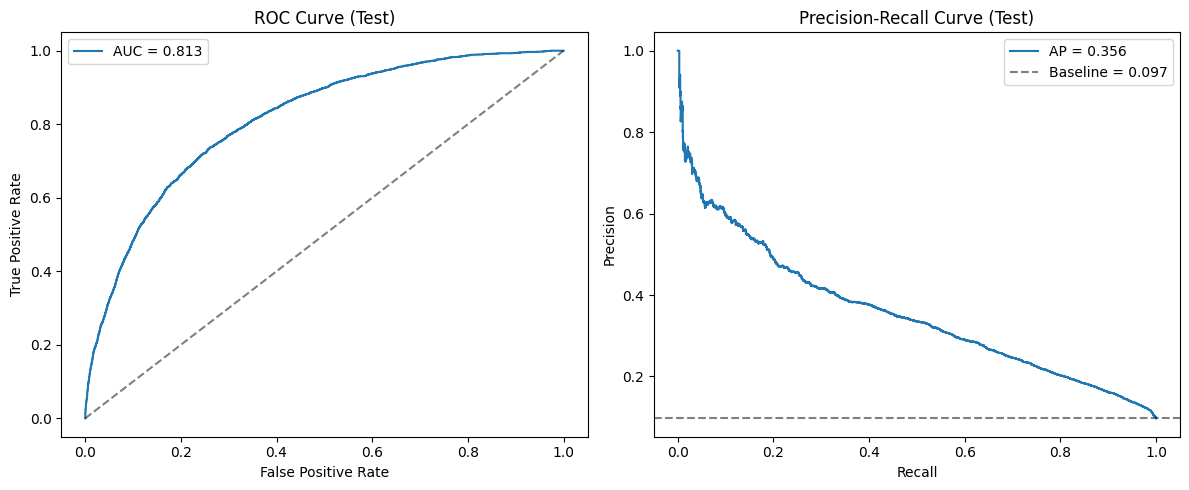

In [7]:
# === CELL 7: ROC and PR Curves ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_prob_test)
    axes[0].plot(fpr, tpr, label=f"AUC = {metrics['test']['roc_auc']:.3f}")
else:
    axes[0].text(0.5, 0.5, "ROC undefined (single class)", ha="center", va="center")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (Test)")
axes[0].legend()

precision, recall, _ = precision_recall_curve(y_test, y_prob_test)
baseline = y_test.mean()
axes[1].plot(recall, precision, label=f"AP = {metrics['test']['pr_auc']:.3f}")
axes[1].axhline(y=baseline, color="k", linestyle="--", alpha=0.5, label=f"Baseline = {baseline:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (Test)")
axes[1].legend()

plt.tight_layout()
plt.savefig(ARTIFACT_PATH / "roc_pr_curves.png", dpi=150)
plt.show()


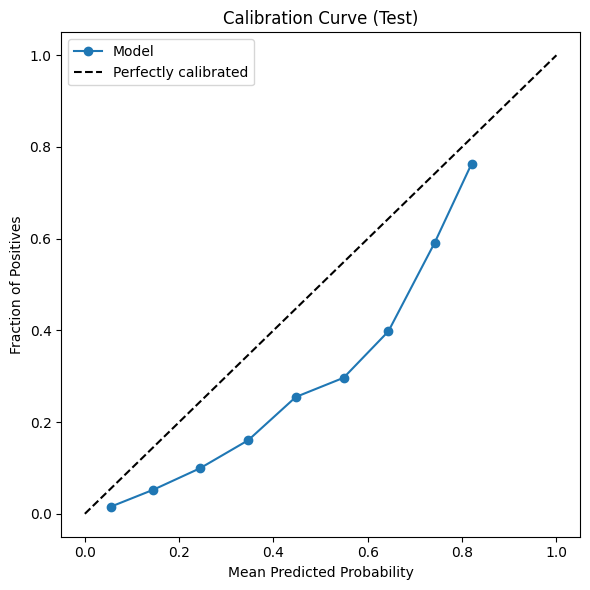

In [8]:
# === CELL 8: Calibration Curve ===
fig, ax = plt.subplots(figsize=(6, 6))

if 0 < y_test.sum() < len(y_test):
    fraction_pos, mean_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="uniform")

    ax.plot(mean_pred, fraction_pos, "o-", label="Model")
    ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title("Calibration Curve (Test)")
    ax.legend()
else:
    ax.text(0.5, 0.5, "Calibration undefined (single class)", ha="center", va="center")

plt.tight_layout()
plt.savefig(ARTIFACT_PATH / "calibration_curve.png", dpi=150)
plt.show()


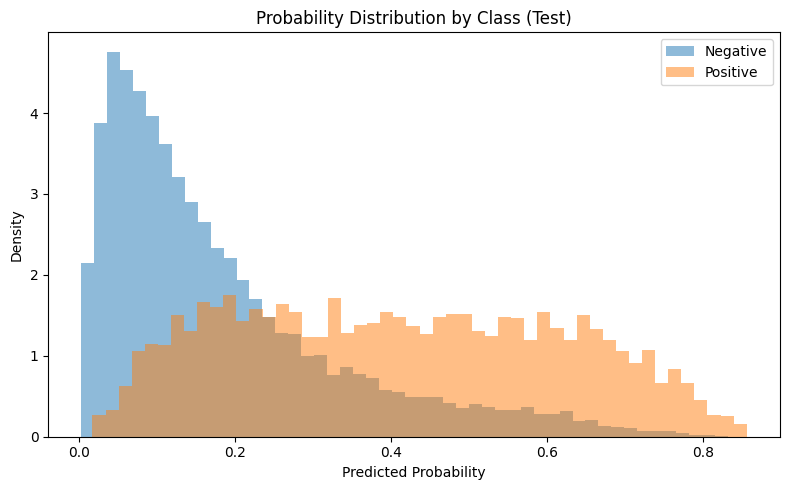

In [9]:
# === CELL 9: Probability Histograms ===
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(y_prob_test[y_test == 0], bins=50, alpha=0.5, label="Negative", density=True)
ax.hist(y_prob_test[y_test == 1], bins=50, alpha=0.5, label="Positive", density=True)
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Density")
ax.set_title("Probability Distribution by Class (Test)")
ax.legend()

plt.tight_layout()
plt.savefig(ARTIFACT_PATH / "probability_histogram.png", dpi=150)
plt.show()


In [10]:
# === CELL 10: Feature Importance ===
importance = model.get_feature_importance(type="PredictionValuesChange")
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance
}).sort_values("importance", ascending=False)

selected_features = importance_df.head(TOP_K)["feature"].tolist()

print(f"=== Top {TOP_K} Features ===")
print(importance_df.head(TOP_K).to_string(index=False))


=== Top 120 Features ===
                         feature  importance
                      minute_sin    4.017179
           return_rolling_mean_8    3.188091
          return_rolling_mean_12    2.686168
                      minute_cos    2.107820
    parkinson_var_rolling_mean_2    1.278310
          return_rolling_mean_24    1.228646
           return_rolling_mean_4    1.168181
        range_pct_rolling_mean_4    1.060071
  log_quote_volume_rolling_max_1    0.813598
        range_pct_rolling_mean_2    0.799565
                      true_range    0.778520
 log_quote_volume_rolling_mean_1    0.744769
         range_pct_rolling_min_1    0.743865
    parkinson_var_rolling_mean_4    0.742272
           return_rolling_mean_2    0.722484
     parkinson_var_rolling_max_1    0.699769
          range_hl_rolling_max_1    0.696015
                        range_hl    0.678765
          range_hl_rolling_max_2    0.673565
            return_rolling_min_2    0.657251
         range_hl_rolling_mean

In [11]:
# === CELL 11: Save Artifacts ===
model.save_model(str(ARTIFACT_PATH / "model.cbm"))

with open(ARTIFACT_PATH / "selected_features.json", "w") as f:
    json.dump({"features": selected_features}, f, indent=2)

with open(ARTIFACT_PATH / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

importance_df.to_csv(ARTIFACT_PATH / "feature_importance.csv", index=False)

config_snapshot = {
    "model_config": model_config,
    "feature_metadata": feature_meta,
}
with open(ARTIFACT_PATH / "config_snapshot.json", "w") as f:
    json.dump(config_snapshot, f, indent=2)

print(f"Artifacts saved to: {ARTIFACT_PATH}")


Artifacts saved to: C:\Users\vitil\OneDrive\Desktop\online_barrier_classifier\artifacts\offline_model
